Dataset Preview:
    Customer Id  Age  Edu  Years Employed  Income  Card Debt  Other Debt  \
0            1   41    2               6      19      0.124       1.073   
1            2   47    1              26     100      4.582       8.218   
2            3   33    2              10      57      6.111       5.802   
3            4   29    2               4      19      0.681       0.516   
4            5   47    1              31     253      9.308       8.908   

   Defaulted Address  DebtIncomeRatio  
0        0.0  NBA001              6.3  
1        0.0  NBA021             12.8  
2        1.0  NBA013             20.9  
3        0.0  NBA009              6.3  
4        0.0  NBA008              7.2   



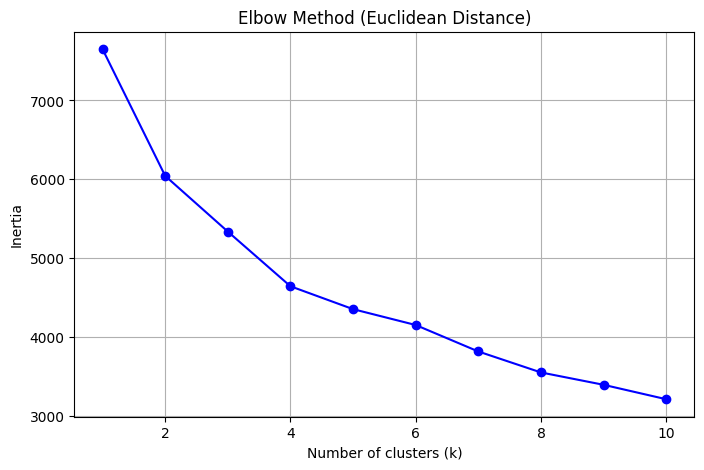

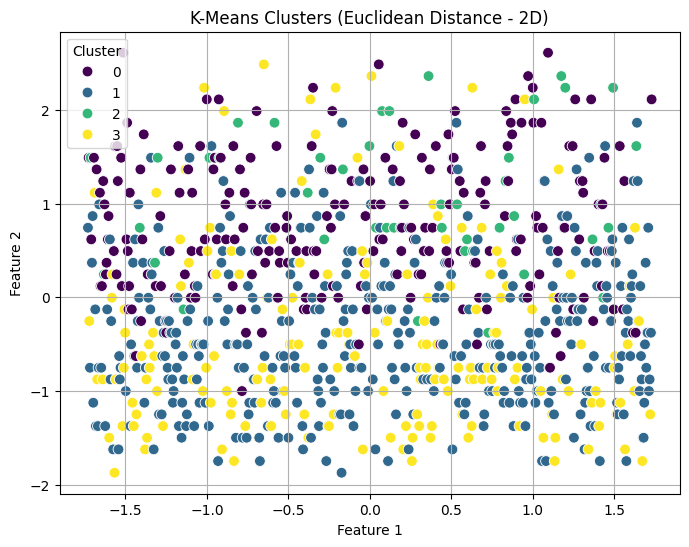

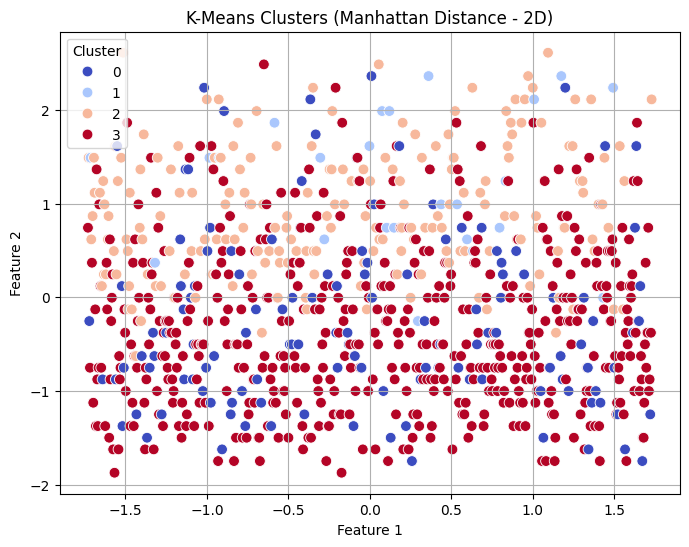

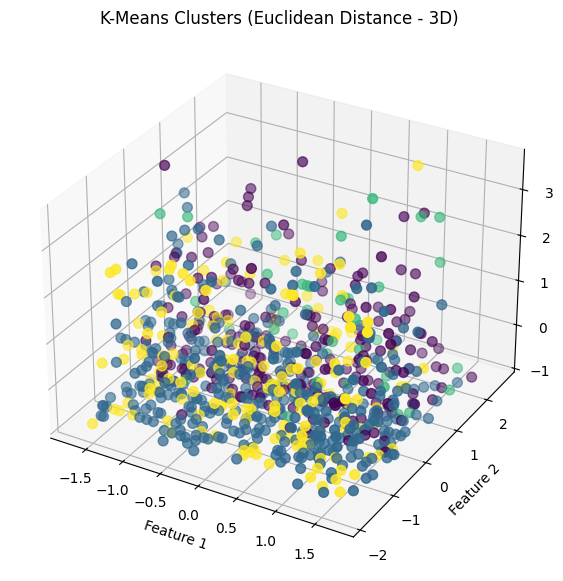

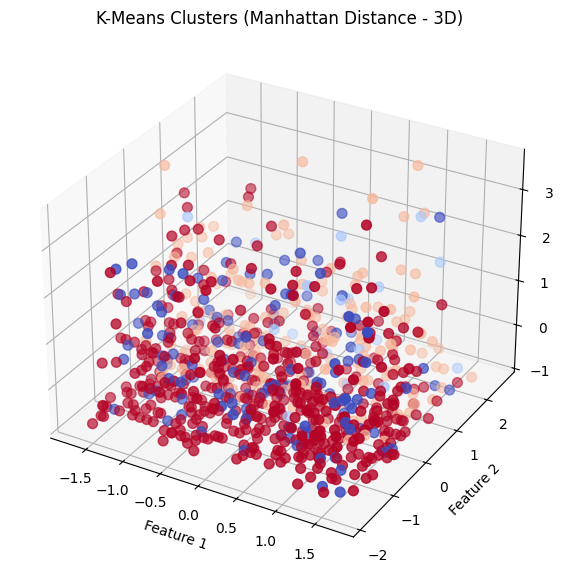

Cluster Counts (Euclidean):
 Cluster_Euclidean
1    403
0    227
3    177
2     43
Name: count, dtype: int64 

Cluster Counts (Manhattan):
 Cluster_Manhattan
3    503
2    195
0    128
1     24
Name: count, dtype: int64 



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.spatial.distance import cdist

data = pd.read_csv("Cust_Segmentation.csv")
print("Dataset Preview:\n", data.head(), "\n")


if 'Address' in data.columns:
    data = data.drop(columns=['Address'])

X = data.select_dtypes(include=[np.number])

X = X.fillna(X.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.title('Elbow Method (Euclidean Distance)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

kmeans_euclidean = KMeans(n_clusters=4, random_state=42)
labels_euclidean = kmeans_euclidean.fit_predict(X_scaled)

def kmeans_manhattan(X, k, max_iters=100):
    np.random.seed(42)
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    for _ in range(max_iters):
        distances = cdist(X, centroids, metric='cityblock')
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

labels_manhattan, centroids_manhattan = kmeans_manhattan(X_scaled, k=4)

data['Cluster_Euclidean'] = labels_euclidean
data['Cluster_Manhattan'] = labels_manhattan

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_scaled[:, 0], y=X_scaled[:, 1],
    hue=labels_euclidean, palette='viridis', s=60
)
plt.title("K-Means Clusters (Euclidean Distance - 2D)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_scaled[:, 0], y=X_scaled[:, 1],
    hue=labels_manhattan, palette='coolwarm', s=60
)
plt.title("K-Means Clusters (Manhattan Distance - 2D)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
    c=labels_euclidean, cmap='viridis', s=50
)
ax.set_title("K-Means Clusters (Euclidean Distance - 3D)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.show()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
    c=labels_manhattan, cmap='coolwarm', s=50
)
ax.set_title("K-Means Clusters (Manhattan Distance - 3D)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.show()

print("Cluster Counts (Euclidean):\n", data['Cluster_Euclidean'].value_counts(), "\n")
print("Cluster Counts (Manhattan):\n", data['Cluster_Manhattan'].value_counts(), "\n")